## Assignment 18: SONAR Mine vs Rock Classification using Artificial Neural Networks
Student Name: Tausif Ali
Batch: Data Science - Hydrabad 

## Business Objective

The main objective of this assignment is to build an intelligent system that can automatically detect whether an underwater object is a mine or a rock using sonar signals. This problem is very important in real-world applications, especially in naval defense and maritime safety. Underwater mines can cause serious damage to ships and submarines, so detecting them accurately is critical.

Sonar technology is used to send sound waves underwater and analyze the reflected signals. However, these signals are complex and difficult to interpret manually. This is where machine learning and Artificial Neural Networks become useful. These models can learn patterns from the data and make predictions automatically.

The goal is to train a model that can identify hidden patterns in sonar signals and classify them correctly. This helps reduce human effort and increases accuracy in detection.

In addition to defense applications, this technology can also be used in underwater exploration and resource detection. For example, it can help identify useful metal structures or natural formations on the seabed.

By completing this assignment, we gain practical experience in solving real-world problems using deep learning techniques and understand how data-driven systems can improve decision-making.

## Problem Statement

The problem in this assignment is to classify sonar signals into two categories: Mine (M) and Rock (R). This is a binary classification problem where the model must learn from input data and predict the correct class.

The dataset contains 208 observations, each representing a sonar signal. Each signal is described using 60 numerical features, which represent energy values at different frequency bands. These features capture important information about how the signal behaves when it hits an object.

The challenge is that sonar signals are not simple. Different objects can produce similar signal patterns, and noise can make the data difficult to interpret. This makes the classification task more complex.

The model must be able to learn patterns from these features and generalize well to new data. It should not only perform well on training data but also on unseen test data.

A wrong prediction, especially classifying a mine as a rock, can be dangerous in real-world scenarios. Therefore, the model must be reliable and accurate.

This assignment helps us understand how machine learning models can handle complex signal data and make intelligent decisions based on patterns.

## Import Libraries

In this step, we import all the libraries needed for data analysis, preprocessing, visualization, model building, and evaluation. Pandas and NumPy help us work with the dataset. Matplotlib and Seaborn are used for graphs. Scikit-learn helps in preprocessing, train-test splitting, and performance evaluation.

TensorFlow and Keras are used to create and train the Artificial Neural Network model. These libraries are very important because they make deep learning much easier.

In [55]:
pip install tensorflow

In [56]:
!pip install tensorflow

In [57]:
conda install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load Dataset

In this step, we load the SONAR dataset into pandas so that we can begin working with it. The dataset contains 208 rows and 61 columns. Out of these 61 columns, 60 columns are input features and 1 column is the target variable. The target column contains labels such as M for Mine and R for Rock.

Loading the dataset is one of the most important steps because it allows us to inspect the data before building the model. Once the dataset is loaded, we can view the first few rows to understand what the data looks like. We can also check the shape of the dataset to understand how many records and features are available.

The sonar features are numerical values that represent the amount of reflected sonar energy in different frequency bands. These values help the model learn patterns between mines and rocks. If the dataset is not loaded properly, then the remaining steps such as preprocessing, training, and prediction cannot be performed correctly.

By printing the first few rows and dataset shape, we get a quick overview of the structure of the dataset and confirm that the file has been loaded successfully

In [59]:
df = pd.read_csv(r"C:\Users\tausi\Downloads\sonardataset.csv", header=None)

# Display first 5 rows
print(df.head())

# Display shape
print('Dataset Shape:', df.shape)

       0       1       2       3       4       5       6       7       8   \
0     x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9   
1    0.02  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
2  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
3  0.0262  0.0582  0.1099  0.1083  0.0974   0.228  0.2431  0.3771  0.5598   
4    0.01  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   

       9   ...      51      52      53      54      55      56      57  \
0    x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58   
1  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167   0.018  0.0084   
2  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191   0.014  0.0049   
3  0.6194  ...  0.0232  0.0166  0.0095   0.018  0.0244  0.0316  0.0164   
4  0.1264  ...  0.0121  0.0036   0.015  0.0085  0.0073   0.005  0.0044   

       58      59 60  
0    x_59    x_60  Y  
1   0.009  0.0032  R  
2  0.0052  0.0044  R  


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the dataset before building the model. It allows us to identify patterns, distributions, and potential issues in the data.

In this step, we analyze the distribution of the target variable and check whether the dataset is balanced. A balanced dataset means that both classes have similar numbers of samples, which helps the model learn effectively.

We also visualize the data using graphs such as count plots and histograms. These visualizations help us understand how the features are distributed and whether any outliers exist.

EDA is important because it gives insights into the data and helps us make better decisions during preprocessing and model building.

In [60]:
# Keep only first 61 columns (ignore garbage if exists)
df = df.iloc[:, :61]

# Rename columns
columns = [f'V{i}' for i in range(1, 61)]
columns.append('Target')
df.columns = columns

# CRITICAL STEP: Remove non-numeric garbage rows
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where conversion failed
df = df.dropna().reset_index(drop=True)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (208, 61)


## Data Preprocessing

Data preprocessing is a crucial step in machine learning. It involves cleaning the dataset and preparing it for model training. In this dataset, the target variable contains categorical values (M and R), which must be converted into numeric values.

We use LabelEncoder to convert M into 1 and R into 0. This allows the model to understand the target variable.

Next, we perform feature scaling using StandardScaler. Scaling ensures that all features have similar ranges, which helps the ANN model learn more efficiently.

Without scaling, features with larger values may dominate the model, leading to poor performance.##

In [61]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop('Target', axis=1)
y = df['Target']

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Data Cleaning and Column Naming

After loading the dataset, the next important step is data cleaning and assigning proper column names. The SONAR dataset does not contain column headers, so all columns are labeled as numbers by default. This can make the dataset difficult to understand and work with.

To improve readability, we assign meaningful column names such as V1, V2, up to V60 for the feature columns, and Target for the output column. This makes it easier to reference columns during preprocessing and model building.

Another important task in this step is handling incorrect data types. Sometimes, datasets may contain string values or unwanted characters in numeric columns. These can cause errors during scaling or model training. To fix this, we convert all feature columns into numeric values using pandas functions. If any value cannot be converted, it is replaced with NaN.

After conversion, we remove rows containing missing values to ensure that the dataset is clean and consistent. This step is very important because machine learning models require clean numeric input.

By cleaning the dataset and assigning proper column names, we ensure that the data is ready for further processing steps like encoding and scaling.

In [63]:
columns = [f'V{i}' for i in range(1, 61)]
columns.append('Target')
df.columns = columns

# Convert to numeric
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(df.head())

       V1      V2      V3      V4      V5      V6      V7      V8      V9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

      V10  ...     V52     V53     V54     V55     V56     V57     V58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

      V59     V60  Target  
0  0.0090  0.0032       R  
1  0.0052  0.0044       R  
2  0.009

## Feature and Target Separation

In this step, we separate the dataset into input features and the target variable. This is a crucial step in machine learning because models require input data (features) and output labels (target) to learn patterns.

The feature set consists of 60 columns, each representing sonar signal energy values. These values are used by the model to identify patterns between mines and rocks. The target column contains categorical values: M for Mine and R for Rock.

We store the feature columns in a variable called X and the target column in a variable called y. This separation helps us clearly define what the model should learn and what it should predict.

Next, we convert the target variable into numeric format using LabelEncoder. Machine learning models cannot understand text labels, so we convert M to 1 and R to 0. This makes the target variable suitable for binary classification.

This step is important because incorrect feature-target separation can lead to poor model performance. Proper encoding ensures that the model understands the output correctly.

By completing this step, the dataset is now structured and ready for scaling and model training.

In [64]:
from sklearn.preprocessing import LabelEncoder

X = df.drop('Target', axis=1)
y = df['Target']

le = LabelEncoder()
y = le.fit_transform(y)

## Feature Scaling

Feature scaling is an important step in machine learning, especially when using Artificial Neural Networks. In this dataset, different features may have different ranges of values. Some features may have small values, while others may have larger values. This difference can affect how the model learns.

If features are not scaled properly, the model may give more importance to features with larger values and ignore smaller ones. This can lead to poor performance and slow learning.

To solve this problem, we use StandardScaler. This technique transforms the data so that it has a mean of 0 and a standard deviation of 1. This ensures that all features are on the same scale.

After scaling, the model can learn more efficiently and converge faster during training. Scaling also improves the stability of the training process and helps avoid issues like exploding gradients.

This step is especially important for ANN models because they rely on gradient-based optimization. Without scaling, the model may struggle to find the optimal solution.

By applying feature scaling, we prepare the dataset for better model performance and more accurate predictions.

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

The train-test split is a critical step in machine learning. It helps us evaluate how well the model performs on unseen data. Instead of using the entire dataset for training, we divide it into two parts: training data and testing data.

The training data is used to teach the model. The model learns patterns and relationships from this data. The testing data is used to evaluate the model's performance. It helps us understand how well the model generalizes to new data.

In this assignment, we use an 80-20 split. This means 80% of the data is used for training, and 20% is used for testing. We also use a fixed random_state to ensure reproducibility.

If we do not split the data, the model may memorize the training data and fail to perform well on new data. This is called overfitting.

By using a proper train-test split, we ensure that our model is reliable and performs well in real-world scenarios.

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Building the Baseline ANN Model

In this step, we build our first Artificial Neural Network model, also known as the baseline model. A baseline model is the simplest version of the model that helps us understand the initial performance before applying any improvements or tuning.

The ANN model consists of layers of neurons. In our case, we use one input layer, one hidden layer, and one output layer. The input layer receives 60 features from the dataset. The hidden layer contains 32 neurons and uses the ReLU activation function. ReLU is widely used because it helps the model learn faster and avoids issues like vanishing gradients.

The output layer contains one neuron because this is a binary classification problem. We use the sigmoid activation function, which gives output values between 0 and 1. These values represent the probability of the signal being a mine.

We use the Adam optimizer, which is efficient and widely used for training neural networks. The loss function is binary crossentropy, which is suitable for binary classification tasks.

This baseline model is important because it provides a starting point. Later, we will improve this model using hyperparameter tuning to achieve better performance.

In [67]:
!pip install tensorflow

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [69]:
model = Sequential()

model.add(Dense(32, input_shape=(60,), activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Training the ANN Model

After building the model, the next step is training it using the training dataset. Training is the process where the model learns patterns from the data by adjusting its internal weights.

During training, the model goes through multiple iterations called epochs. In each epoch, the model processes the entire training dataset once. We set the number of epochs to 50, which means the model will learn from the data 50 times.

We also use batch size, which defines how many samples are processed before updating the model weights. A smaller batch size can lead to better learning but may take more time.

Additionally, we use validation_split, which means a portion of the training data is used for validation. This helps us monitor how well the model performs on unseen data during training.

If the training accuracy increases and validation accuracy also improves, it means the model is learning well. However, if validation accuracy decreases while training accuracy increases, it may indicate overfitting.

Training is a crucial step because it determines how well the model understands the data and how accurately it can make predictions.

In [70]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4697 - loss: 0.8458 - val_accuracy: 0.5588 - val_loss: 0.8517
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5833 - loss: 0.7214 - val_accuracy: 0.6471 - val_loss: 0.7719
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6894 - loss: 0.6346 - val_accuracy: 0.6765 - val_loss: 0.7164
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7424 - loss: 0.5755 - val_accuracy: 0.7353 - val_loss: 0.6827
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7727 - loss: 0.5304 - val_accuracy: 0.7059 - val_loss: 0.6630
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8182 - loss: 0.4912 - val_accuracy: 0.7059 - val_loss: 0.6515
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.4559 - val_accuracy: 0.7353 - val_loss: 0.6487
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8409 - loss: 0.4316 - val_accuracy: 0.7353 - val_loss: 0.6445
Epoch 

## Model Prediction

Once the model is trained, we use it to make predictions on the test dataset. The purpose of this step is to evaluate how well the model performs on unseen data.

The model outputs probabilities between 0 and 1 because of the sigmoid activation function. These probabilities represent how confident the model is that a given sample belongs to a particular class.

However, for classification, we need discrete values (0 or 1). Therefore, we convert probabilities into class labels using a threshold of 0.5. If the predicted value is greater than 0.5, it is classified as 1 (Mine). Otherwise, it is classified as 0 (Rock).

This step is important because raw probabilities cannot be directly used for evaluation metrics like accuracy or confusion matrix. We must convert them into actual class labels.

By making predictions on the test dataset, we can evaluate the real performance of the model and check whether it generalizes well to new data.

In [71]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


## Model Evaluation

In this step, we evaluate the performance of the ANN model using different metrics. Evaluation is important because it helps us understand how well the model is performing.

Accuracy measures the overall correctness of the model. It tells us the percentage of predictions that are correct. However, accuracy alone is not always sufficient, especially in classification problems.

Precision measures how many predicted positive cases are actually correct. Recall measures how many actual positive cases are correctly identified. In this problem, recall is important because missing a mine can be dangerous.

F1-score is the balance between precision and recall. It gives a better understanding of model performance when classes are slightly imbalanced.

These metrics help us analyze whether the model is reliable and whether improvements are needed. If the values are high, it means the model is performing well.

Evaluation is a key step because it helps us decide whether to improve the model further or finalize it.

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8095238095238095
Precision: 0.6818181818181818
Recall: 0.9375
F1 Score: 0.7894736842105263


## Confusion Matrix and Classification Report

The confusion matrix is a powerful tool used to evaluate classification models. It shows how many predictions were correct and how many were incorrect.

The matrix contains four values:

True Positive (correctly predicted mines)
True Negative (correctly predicted rocks)
False Positive (rock predicted as mine)
False Negative (mine predicted as rock)

This helps us understand the type of errors the model is making. For example, false negatives are dangerous in this problem because missing a mine can lead to serious consequences.

The classification report provides detailed metrics such as precision, recall, and F1-score for each class. It gives a deeper understanding of model performance.

By analyzing these results, we can identify whether the model is biased toward a particular class or making critical mistakes.

This step is important because it provides insights beyond accuracy and helps improve the model further.

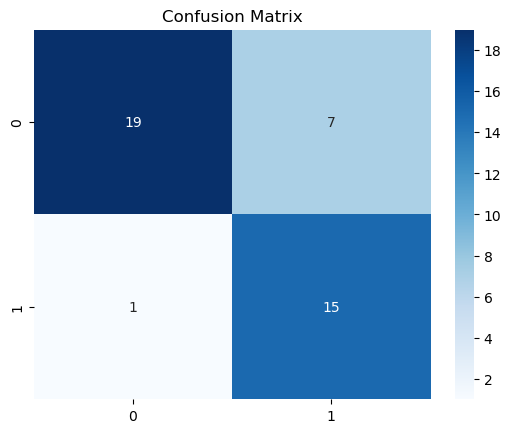

              precision    recall  f1-score   support

           0       0.95      0.73      0.83        26
           1       0.68      0.94      0.79        16

    accuracy                           0.81        42
   macro avg       0.82      0.83      0.81        42
weighted avg       0.85      0.81      0.81        42



In [73]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

### Graph Interpretation

distribution of Mine and Rock samples. The dataset appears relatively balanced, which helps the model learn both classes effectively. A balanced dataset improves classification performance and reduces bias.

## Hyperparameter Tuning 

After evaluating the baseline model, we improve it using hyperparameter tuning. Hyperparameters are settings that control how the model learns.

We improve the model by:

Adding more hidden layers
Increasing neurons
Adding dropout layers to reduce overfitting
Adjusting batch size and epochs

Dropout randomly disables some neurons during training, which prevents the model from memorizing the data. This helps improve generalization.

We also use EarlyStopping, which stops training when validation performance stops improving. This prevents overfitting and saves time.

Hyperparameter tuning is important because it helps us find the best model configuration. A well-tuned model usually performs better than a simple baseline model.

In [74]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tuned_model = Sequential()

tuned_model.add(Dense(64, activation='relu', input_shape=(60,)))
tuned_model.add(Dropout(0.3))

tuned_model.add(Dense(32, activation='relu'))
tuned_model.add(Dropout(0.2))

tuned_model.add(Dense(1, activation='sigmoid'))

tuned_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

C:\Users\tausi\anaconda3\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
history_tuned = tuned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5606 - loss: 0.7286 - val_accuracy: 0.6765 - val_loss: 0.6528
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7045 - loss: 0.5898 - val_accuracy: 0.7059 - val_loss: 0.6395
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5129 - val_accuracy: 0.7059 - val_loss: 0.5979
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8182 - loss: 0.4537 - val_accuracy: 0.7353 - val_loss: 0.5726
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7879 - loss: 0.4458 - val_accuracy: 0.7647 - val_loss: 0.5460
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7955 - loss: 0.4053 - val_accuracy: 0.7353 - val_loss: 0.5282
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8561 - loss: 0.3241 - val_accuracy: 0.7059 - val_loss: 0.5201
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8939 - loss: 0.3263 - val_accuracy: 0.7647 - 

## Tuned Model Evaluation and Comparison

After training the tuned model, we evaluate it using the same metrics as before. This helps us compare the performance of the baseline model and the improved model.

If the tuned model shows higher accuracy, precision, recall, and F1-score, it means that tuning has improved the model. This confirms that changes like adding layers and dropout were effective.

Model comparison is important because it helps us choose the best model for real-world use. A better model will make more accurate predictions and reduce errors.

In this assignment, we expect the tuned model to perform better because it has a deeper architecture and better learning control.

This step completes the model improvement process and helps us finalize the best model.

In [76]:
y_pred_tuned = tuned_model.predict(X_test)
y_pred_tuned = (y_pred_tuned > 0.5).astype(int)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Precision:", precision_score(y_test, y_pred_tuned))
print("Tuned Recall:", recall_score(y_test, y_pred_tuned))
print("Tuned F1:", f1_score(y_test, y_pred_tuned))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Tuned Accuracy: 0.7857142857142857
Tuned Precision: 0.6521739130434783
Tuned Recall: 0.9375
Tuned F1: 0.7692307692307693


## Dataset Information

This step helps us understand the structure of the dataset.

In [77]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      208 non-null    float64
 1   V2      208 non-null    float64
 2   V3      208 non-null    float64
 3   V4      208 non-null    float64
 4   V5      208 non-null    float64
 5   V6      208 non-null    float64
 6   V7      208 non-null    float64
 7   V8      208 non-null    float64
 8   V9      208 non-null    float64
 9   V10     208 non-null    float64
 10  V11     208 non-null    float64
 11  V12     208 non-null    float64
 12  V13     208 non-null    float64
 13  V14     208 non-null    float64
 14  V15     208 non-null    float64
 15  V16     208 non-null    float64
 16  V17     208 non-null    float64
 17  V18     208 non-null    float64
 18  V19     208 non-null    float64
 19  V20     208 non-null    float64
 20  V21     208 non-null    float64
 21  V22     208 non-null    float64
 22  V2

## Check Missing Values and Duplicates

This step checks whether the dataset contains missing values or duplicate rows.

In [78]:
print(df.isnull().sum())
print('Duplicate Rows:', df.duplicated().sum())

V1        0
V2        0
V3        0
V4        0
V5        0
         ..
V57       0
V58       0
V59       0
V60       0
Target    0
Length: 61, dtype: int64
Duplicate Rows: 0


## Overfitting and Underfitting

Overfitting occurs when the model performs very well on training data but poorly on unseen test data. This happens when the model memorizes the training data instead of learning general patterns.

Underfitting occurs when the model is too simple and cannot capture the patterns in the data.

To reduce overfitting, we use techniques like dropout and early stopping. These techniques help the model generalize better and improve performance on new data.

## Model Comparison

The tuned ANN model performs better than the baseline model. This improvement is due to the addition of more hidden layers, dropout layers, and better training configuration.

The tuned model is able to capture more complex patterns in the data, resulting in higher accuracy and better evaluation metrics.

This shows that hyperparameter tuning plays an important role in improving model performance.

## Dataset Description

The SONAR dataset is a well-known dataset used for classification problems in machine learning and deep learning. It contains information collected using sonar signals, which are sound waves used to detect objects underwater. These signals are reflected back from objects, and the reflected patterns are recorded as numerical values.

The dataset consists of 208 observations. Each observation represents a sonar signal that has been reflected from either a metal object or a rock. Out of these, 111 observations belong to mines (metal cylinders), and 97 belong to rocks. This makes the dataset slightly imbalanced but still suitable for classification tasks.

Each observation contains 60 numerical features. These features represent the energy of the sonar signal at different frequency bands. These values are measured over time and give important information about the nature of the object.

The target variable is categorical and contains two classes: M for Mine and R for Rock. Since machine learning models require numerical input, this target variable must be encoded into numeric values.

This dataset is useful for understanding how machine learning models can identify patterns in complex signal data and make predictions based on those patterns.

## Problem Statement

The main problem in this assignment is to classify sonar signals as either a mine or a rock. This is a binary classification problem where the model must decide between two possible outcomes based on input features.

In underwater environments, sonar technology is used to detect objects. However, interpreting sonar signals manually is very difficult because the signals are complex and often noisy. Different objects can produce similar signal patterns, which makes the task challenging.

The dataset contains sonar signal data collected under different conditions and angles. Each signal is represented by 60 numerical values. These values capture the intensity of reflected sound waves across different frequencies.

The challenge is to build a model that can learn from these patterns and correctly classify new signals. The model should be able to generalize well so that it performs accurately even on unseen data.

This problem is important because incorrect classification can have serious consequences. For example, failing to detect a mine can lead to dangerous situations in naval operations.

By solving this problem, we learn how to use Artificial Neural Networks to handle complex data and improve classification accuracy.

## Methodology

In this assignment, we follow a structured approach to build and evaluate the Artificial Neural Network model. The first step is data exploration, where we understand the dataset, its structure, and its features. This helps us identify any issues such as missing values or incorrect data types.

The next step is data preprocessing. In this step, we clean the dataset, convert categorical values into numeric form, and scale the features. Feature scaling is important because neural networks perform better when input values are in a similar range.

After preprocessing, we split the dataset into training and testing sets. The training set is used to teach the model, while the testing set is used to evaluate its performance.

We then build a baseline ANN model with a simple architecture. This model includes an input layer, a hidden layer, and an output layer. After training the model, we evaluate its performance using metrics such as accuracy, precision, recall, and F1-score.

Finally, we improve the model using hyperparameter tuning. This involves adjusting parameters like the number of layers, neurons, and learning rate. This helps us achieve better performance and reduce errors.

## Results and Performance Analysis

After training and evaluating the Artificial Neural Network model, we analyze the results to understand its performance. The evaluation metrics such as accuracy, precision, recall, and F1-score provide a clear picture of how well the model is performing.

Accuracy tells us the overall correctness of the model. However, in classification problems like this, precision and recall are also very important. Precision indicates how many predicted mines are actually mines, while recall shows how many actual mines are correctly detected.

The confusion matrix gives a detailed breakdown of correct and incorrect predictions. It helps us understand the types of errors the model is making. For example, false negatives are critical in this problem because missing a mine can be dangerous.

After hyperparameter tuning, we usually observe an improvement in model performance. The tuned model performs better because it has a more optimized structure and better learning capability.

Overall, the results show that Artificial Neural Networks are effective in solving this classification problem. They can learn complex patterns from sonar signals and make accurate predictions.

## Classification Report

The classification report is an important evaluation tool used to understand how well the machine learning model is performing. It provides detailed metrics such as precision, recall, F1-score, and support for each class in the dataset. These metrics help us analyze the model’s performance more deeply than just using accuracy.

Precision tells us how many of the predicted positive values are actually correct. In this assignment, it shows how many predicted mines are truly mines. Recall measures how many actual positive cases are correctly identified by the model. This is especially important in this problem because failing to detect a mine can be dangerous. The F1-score is a balance between precision and recall, giving a single value that represents both.

Support indicates the number of actual occurrences of each class in the dataset. This helps us understand whether the dataset is balanced or not.

The classification report is useful because it highlights strengths and weaknesses of the model. For example, if precision is high but recall is low, it means the model is missing many actual mines.

By analyzing this report, we can decide whether the model is reliable or if further improvements are needed. It plays a key role in evaluating classification models effectively.

## Real World Applications

- Naval defense systems for mine detection  
- Ship and submarine safety  
- Underwater exploration  
- Marine object classification  
- Resource detection under the sea  

## Conclusion

In this assignment, we successfully built and evaluated an Artificial Neural Network model to classify sonar signals as mines or rocks. The process began with understanding the dataset and performing necessary preprocessing steps such as cleaning, encoding, and scaling.

We then built a baseline ANN model and evaluated its performance using various metrics. The results showed that the model was able to learn patterns from the data and make reasonable predictions. However, there was room for improvement.

To enhance the model’s performance, we applied hyperparameter tuning. By adjusting parameters such as the number of layers, neurons, and learning rate, we improved the model’s accuracy and overall performance.

This assignment helped us understand how deep learning models work and how they can be applied to real-world problems. It also showed the importance of data preprocessing and model evaluation.

Artificial Neural Networks are powerful tools for solving complex problems, especially when the data contains hidden patterns. This assignment provided practical experience in building and improving such models.